In [10]:
# importing necessary library
import numpy as np
import pandas as pd
import scipy.stats as stats
import statistics as st

In [11]:
# Reading dataset
df = pd.read_csv("https://drive.google.com/uc?id=12MIS5g_PAq4yXXZpmRwcUUjbLXez6wWL")
df.head(2)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420.0,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960.0,4,4,4,yes,no,no,no,yes,3,no,furnished


In [12]:
# Calculating mean of area
st.mean(df.area)

nan

In [33]:
# Check for null values in dataframe
df.isnull()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
539,False,False,False,False,False,False,False,False,False,False,False,False,False
540,False,False,False,False,False,False,False,False,False,False,False,False,False
541,False,False,False,False,False,False,False,False,False,False,False,False,False
543,False,False,False,False,False,False,False,False,False,False,False,False,False


In [15]:
# Drop the null values
df.dropna(inplace = True)

In [16]:
# Check the mean again for area
st.mean(df.area)

5134.1584905660375

In [20]:
# Compute standard deviation of area
st.stdev(df.area)

2152.6218324780675

In [23]:
# Compute mode for furnishingstatus
st.mode(df.furnishingstatus)

'semi-furnished'

In [26]:
# Print the data stastical summary for int columns only
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.300000e+02,530.000000,530.000000,530.000000,530.000000,530.000000
mean,4.731140e+06,5134.158491,2.962264,1.281132,1.801887,0.688679
std,1.841074e+06,2152.621832,0.739444,0.501626,0.867604,0.862616
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3588.000000,2.000000,1.000000,1.000000,0.000000
50%,4.329500e+06,4540.000000,3.000000,1.000000,2.000000,0.000000
75%,5.718125e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [31]:
# Lets compute the percentiles
np.percentile(df['price'], 10)
np.percentile(df['price'], 20)
np.percentile(df['price'], 30)
np.percentile(df['price'], 40)
np.percentile(df['price'], 50)
np.percentile(df['price'], 60)

np.float64(4762800.0)

In [30]:
# skewness for price
df['price'].skew()

np.float64(1.2555562245135674)

In [32]:
# Kurtosis for price
df['price'].kurtosis()

np.float64(2.232360487969864)

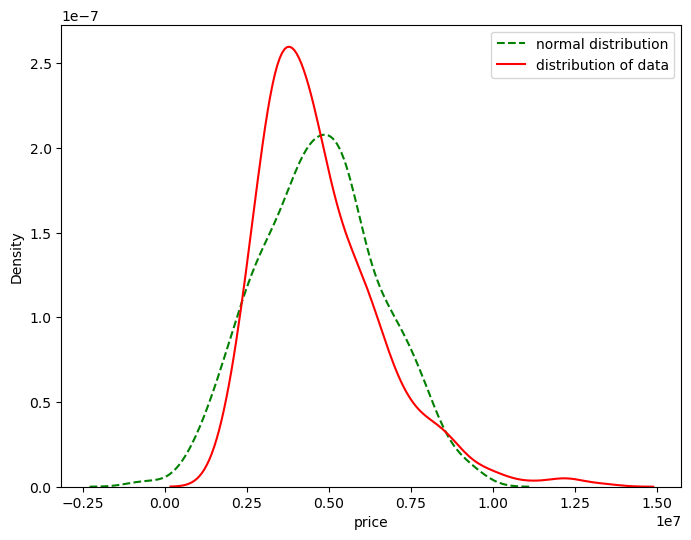

In [45]:
# Visualize the skewness asnd kurtosis
import seaborn as sns
import matplotlib.pyplot as plt

data = np.random.normal(df['price'].mean(), df['price'].std(), size= len(df)) 
plt.figure(figsize = (8,6))
sns.kdeplot(data, label = "normal distribution", color = 'green', linestyle = '--')
sns.kdeplot(df['price'],label = 'distribution of data', color = 'red')
plt.legend()




## One Sample T-test

In [ ]:
# Suppose a manufacturer claims that the average weight of their new
# chocolate bars is 50 grams. We highly doubt that and want to check this,
# so we drew out a sample of 25 chocolate bars and measured their weight.
# Consider the significance level to be 0.05.
sample = [46.9, 47.8, 48.4, 48.8, 49.0, 49.2, 49.3, 49.4, 49.5, 49.6, 49.7, 49.7,
          49.7, 49.8, 49.9, 50.0, 50.1, 50.2, 50.3, 50.5, 50.7, 51.0, 51.4, 51.9, 52.5]

In [47]:
# Paste the value of sample and alpha here

sample = [46.9, 47.8, 48.4, 48.8, 49.0, 49.2, 49.3, 49.4, 49.5, 49.6, 49.7, 49.7,
          49.7, 49.8, 49.9, 50.0, 50.1, 50.2, 50.3, 50.5, 50.7, 51.0, 51.4, 51.9, 52.5]
alpha = 0.05

In [49]:
# Compute the p-value
t_test, p_val = stats.ttest_1samp(sample, 50)
t_test,p_val



(np.float64(-0.7841687728913062), np.float64(0.44061252775449444))

In [50]:
# Check for conditions
if p_val <= alpha:
    print("Reject")
else:
    print("fail to reject")



fail to reject


## Two-Sample t-Test

In [ ]:
# A researcher wants to determine whether there is a significant difference
# in the average age of males and females in a certain community. A random sample
# of 12 males and 12 females was selected.

In [51]:
# here are the samples drawn
male_age = [35, 40, 38, 45, 50, 42, 39, 41, 37, 43, 46, 44]
female_age = [40, 22, 21, 23, 35, 45, 30, 23, 30, 24, 40, 33]
alpha = 0.05

In [52]:
# Let's perform t_test
t_test, p_value = stats.ttest_ind(male_age, female_age)
t_test,p_value



(np.float64(4.203201778149059), np.float64(0.000367315428831697))

In [54]:
# Check for conditions
if p_value/2<= alpha:
    print("Reject")
else:
    print("fail to reject")



Reject
